#Vergleichs- und Ablation-Evaluation: BiLSTM vs. Vanilla RNN Baseline

Dieses Notebook führt eine **quantitative und statistische Evaluation** durch, um das primäre **BiLSTM-Metrik-Modell** (MixUp-Regressor) mit der **Vanilla RNN Baseline** auf dem **Lebenshilfe-Datensatz** zu vergleichen und empirisch zu belegen, welche Modellarchitektur überlegen ist.

####Evaluierte Forschungsfragen:
1. **Diskriminierungsfähigkeit & Separation:** Welches Modell trennt Alltagssprache (AS, Zielwert $\approx 0$) und Leichte Sprache (LS, Zielwert $\approx 1$) deutlicher voneinander?
2. **Klassifikationsmetriken:** Wie schneiden beide Architekturen bei Schwellwert $\theta = 0.5$ bzgl. *Accuracy, Balanced Accuracy, F1-Score und ROC-AUC* ab?
3. **Statistische Distanzmaße:** Vergleich von *Wasserstein-Distanz* ($W_1$) und *Kolmogorov-Smirnov-Statistik* ($D_{KS}$).
4. **Dichteverteilungen (KDE):** Visuelle Analyse der Überlappung der Score-Verteilungen für LS und AS.
5. **Length-Bias & Vanishing Gradients:** Behält das BiLSTM durch Gating und Bidirektionalität eine stabilere Trennung bei variierender Sequenzlänge als das Vanilla RNN?

In [1]:
import os 
import sys 
import json 
import glob 
import numpy as np 
import pandas as pd 
import matplotlib .pyplot as plt 
import seaborn as sns 
from scipy .stats import wasserstein_distance ,ks_2samp 
from sklearn .metrics import (
roc_auc_score ,roc_curve ,accuracy_score ,
balanced_accuracy_score ,precision_recall_fscore_support ,
mean_absolute_error ,mean_squared_error 
)

from IPython .display import display ,Markdown 

#Arbeitsverzeichnis auf Projekt-Root setzen
while not os .path .exists (".git"):
    parent =os .path .dirname (os .getcwd ())
    if parent ==os .getcwd ():
        break 
    os .chdir ("..")

print ("Arbeitsverzeichnis:",os .getcwd ())
PLOT_OUTPUT_DIR ="results/plots"
os .makedirs (PLOT_OUTPUT_DIR ,exist_ok =True )


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


##1. Evaluationsergebnisse laden

In [2]:
CSV_METRICS_PATH ="results/evaluation/bilstm_vs_rnn_eval.csv"
if not os .path .exists (CSV_METRICS_PATH ):
    CSV_METRICS_PATH ="../../../results/evaluation/bilstm_vs_rnn_eval.csv"

CSV_PREDS_PATH ="results/evaluation/bilstm_vs_rnn_predictions.csv"
if not os .path .exists (CSV_PREDS_PATH ):
    CSV_PREDS_PATH ="../../../results/evaluation/bilstm_vs_rnn_predictions.csv"

df_metrics =pd .read_csv (CSV_METRICS_PATH )
df_preds =pd .read_csv (CSV_PREDS_PATH )

print (f"Evaluations-Ergebnisse geladen: {len (df_metrics )} Modelle aus {CSV_METRICS_PATH }")
print (f"Detail-Vorhersagen geladen: {len (df_preds )} Artikelpaare aus {CSV_PREDS_PATH }")
display (df_metrics )

#Vorhersage-Arrays direkt aus den vorberechneten Sbatch-Ergebnissen extrahieren
ls_preds_bilstm =df_preds ["ls_pred_bilstm"].to_numpy ()
as_preds_bilstm =df_preds ["as_pred_bilstm"].to_numpy ()
ls_preds_rnn =df_preds ["ls_pred_rnn"].to_numpy ()
as_preds_rnn =df_preds ["as_pred_rnn"].to_numpy ()


Evaluations-Ergebnisse geladen: 2 Modelle aus results/evaluation/bilstm_vs_rnn_eval.csv
Detail-Vorhersagen geladen: 37 Artikelpaare aus results/evaluation/bilstm_vs_rnn_predictions.csv


,model,mean_as_score,mean_ls_score,separation_margin,roc_auc,accuracy,balanced_accuracy,wasserstein_distance,ks_statistic
0,BiLSTM (MixUp),0.172501,0.670722,0.498221,0.995252,0.932432,0.932432,0.498221,0.945946
1,Vanilla RNN (Baseline),0.343871,0.453851,0.109980,0.822133,0.594595,0.594595,0.109979,0.621622


##2. Statistische Metriken & Direkter Modellvergleich

Wir berechnen alle  relevanten Gütekriterien:
- **Separation $\Delta$:** Differenz $\bar{\lambda}_{\text{LS}} - \bar{\lambda}_{\text{AS}}$ (je größer, desto klarer getrennt).
- **Accuracy & Balanced Accuracy:** Bei Standard-Klassifikationsschwelle $\theta = 0.5$.
- **ROC-AUC:** Schwellwertunabhängige Trennschärfe.
- **Wasserstein-Distanz ($W_1$):** Minimaler Arbeitsaufwand zur Überführung der AS- in die LS-Dichteverteilung.
- **Kolmogorov-Smirnov-Statistik ($D_{KS}$):** Maximaler vertikaler Abstand der empirischen Verteilungsfunktionen.

In [3]:
def calculate_comprehensive_metrics (ls_scores ,as_scores ,model_name ):
# Labels und Vorhersagen zusammenführen
    y_true =np .array ([1 ]*len (ls_scores )+[0 ]*len (as_scores ))
    y_scores =np .concatenate ([ls_scores ,as_scores ])
    y_pred_binary =(y_scores >=0.5 ).astype (int )

    mean_ls =np .mean (ls_scores )
    std_ls =np .std (ls_scores )
    mean_as =np .mean (as_scores )
    std_as =np .std (as_scores )
    separation =mean_ls -mean_as 

    acc =accuracy_score (y_true ,y_pred_binary )
    bacc =balanced_accuracy_score (y_true ,y_pred_binary )
    prec ,rec ,f1 ,_ =precision_recall_fscore_support (y_true ,y_pred_binary ,average ="binary",pos_label =1 )
    auc =roc_auc_score (y_true ,y_scores )
    mae =mean_absolute_error (y_true ,y_scores )
    mse =mean_squared_error (y_true ,y_scores )

    # Distanzmaße
    w_dist =wasserstein_distance (ls_scores ,as_scores )
    ks_stat ,ks_pval =ks_2samp (ls_scores ,as_scores )

    return {
    "Modell":model_name ,
    "Ø Lambda (LS)":f"{mean_ls :.4f} ± {std_ls :.3f}",
    "Ø Lambda (AS)":f"{mean_as :.4f} ± {std_as :.3f}",
    "Separation (Δ)":separation ,
    "Accuracy (@0.5)":acc ,
    "Balanced Acc":bacc ,
    "F1-Score":f1 ,
    "ROC-AUC":auc ,
    "MAE (Target 1/0)":mae ,
    "Wasserstein (W1)":w_dist ,
    "KS-Statistik (D)":ks_stat 
    }

results =[
calculate_comprehensive_metrics (ls_preds_bilstm ,as_preds_bilstm ,"BiLSTM (Hauptmodell)"),
calculate_comprehensive_metrics (ls_preds_rnn ,as_preds_rnn ,"Vanilla RNN (Baseline)")
]

df_comparison =pd .DataFrame (results )

#Formatierte Tabelle für die Anzeige
df_display =df_comparison .copy ()
df_display ["Separation (Δ)"]=df_display ["Separation (Δ)"].apply (lambda x :f"{x :.4f}")
df_display ["Accuracy (@0.5)"]=df_display ["Accuracy (@0.5)"].apply (lambda x :f"{x *100 :.2f}%")
df_display ["Balanced Acc"]=df_display ["Balanced Acc"].apply (lambda x :f"{x *100 :.2f}%")
df_display ["F1-Score"]=df_display ["F1-Score"].apply (lambda x :f"{x *100 :.2f}%")
df_display ["ROC-AUC"]=df_display ["ROC-AUC"].apply (lambda x :f"{x :.4f}")
df_display ["MAE (Target 1/0)"]=df_display ["MAE (Target 1/0)"].apply (lambda x :f"{x :.4f}")
df_display ["Wasserstein (W1)"]=df_display ["Wasserstein (W1)"].apply (lambda x :f"{x :.4f}")
df_display ["KS-Statistik (D)"]=df_display ["KS-Statistik (D)"].apply (lambda x :f"{x :.4f}")

print (r"\n=================== STATISTISCHER MODELLVERGLEICH (LEBENSHILFE) ===================")
display (df_display )



=================== STATISTISCHER MODELLVERGLEICH (LEBENSHILFE) ===================


,Modell,Ø Lambda (LS),Ø Lambda (AS),Separation (Δ),Accuracy (@0.5),Balanced Acc,F1-Score,ROC-AUC,MAE (Target 1/0),Wasserstein (W1),KS-Statistik (D)
0,BiLSTM (Hauptmodell),0.6707 ± 0.123,0.1725 ± 0.091,0.4982,93.24%,93.24%,92.75%,0.9953,0.2509,0.4982,0.9459
1,Vanilla RNN (Baseline),0.4539 ± 0.089,0.3439 ± 0.092,0.1100,59.46%,59.46%,44.44%,0.8221,0.4450,0.1100,0.6216


##3. Visualisierungen

###5.1 KDE-Dichteverteilungsplots (BiLSTM vs. RNN Baseline)
Darstellung der Dichteverteilungen von LS und AS im standardisierten Publikationsdesign.

<>:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_39902/2153664595.py:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[0].set_xlabel("Lambda $\lambda$ (LS-Score)", fontsize=12)
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_39902/2153664595.py:18: SyntaxWar

KDE-Plot gespeichert unter: results/plots/compare_bilstm_vs_rnn_kde.png


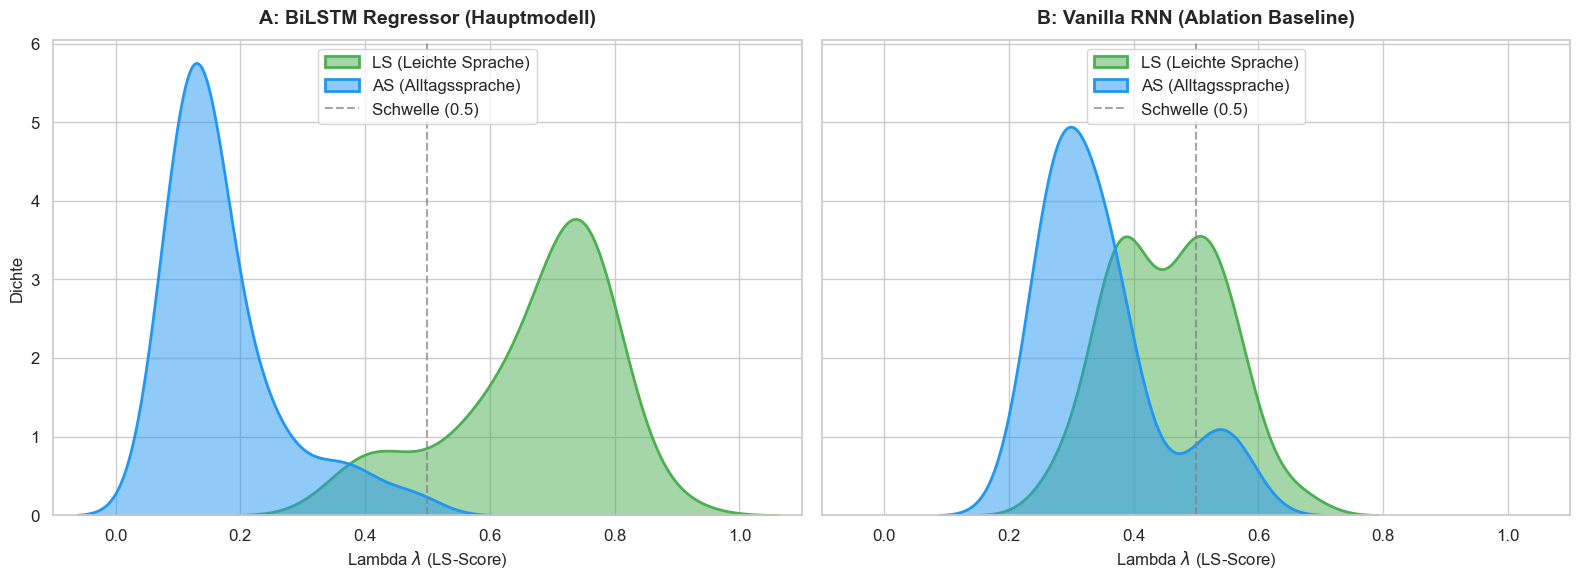

In [4]:
sns .set_theme (style ="whitegrid",font_scale =1.1 )
fig ,axes =plt .subplots (1 ,2 ,figsize =(16 ,6 ),sharey =True )

#Plot 1: BiLSTM
sns .kdeplot (ls_preds_bilstm ,ax =axes [0 ],fill =True ,color ="#4CAF50",label ="LS (Leichte Sprache)",alpha =0.5 ,linewidth =2 )
sns .kdeplot (as_preds_bilstm ,ax =axes [0 ],fill =True ,color ="#2196F3",label ="AS (Alltagssprache)",alpha =0.5 ,linewidth =2 )
axes [0 ].set_title ("A: BiLSTM Regressor (Hauptmodell)",fontsize =14 ,fontweight ="bold",pad =12 )
axes [0 ].set_xlabel (r"Lambda $\lambda$ (LS-Score)",fontsize =12 )
axes [0 ].set_ylabel ("Dichte",fontsize =12 )
axes [0 ].set_xlim (-0.1 ,1.1 )
axes [0 ].axvline (0.5 ,color ="grey",linestyle ="--",alpha =0.7 ,label ="Schwelle (0.5)")
axes [0 ].legend (loc ="upper center",frameon =True )

#Plot 2: RNN Baseline
sns .kdeplot (ls_preds_rnn ,ax =axes [1 ],fill =True ,color ="#4CAF50",label ="LS (Leichte Sprache)",alpha =0.5 ,linewidth =2 )
sns .kdeplot (as_preds_rnn ,ax =axes [1 ],fill =True ,color ="#2196F3",label ="AS (Alltagssprache)",alpha =0.5 ,linewidth =2 )
axes [1 ].set_title ("B: Vanilla RNN (Ablation Baseline)",fontsize =14 ,fontweight ="bold",pad =12 )
axes [1 ].set_xlabel (r"Lambda $\lambda$ (LS-Score)",fontsize =12 )
axes [1 ].set_ylabel ("",fontsize =12 )
axes [1 ].set_xlim (-0.1 ,1.1 )
axes [1 ].axvline (0.5 ,color ="grey",linestyle ="--",alpha =0.7 ,label ="Schwelle (0.5)")
axes [1 ].legend (loc ="upper center",frameon =True )

plt .tight_layout ()
kde_plot_path =os .path .join (PLOT_OUTPUT_DIR ,"compare_bilstm_vs_rnn_kde.png")
plt .savefig (kde_plot_path ,dpi =300 ,bbox_inches ="tight")
print (f"KDE-Plot gespeichert unter: {kde_plot_path }")
plt .show ()


<>:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_39902/3655598402.py:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[1].set_ylabel("Vorhergesagter Lambda-Score $\lambda$")


ROC/Boxplot gespeichert unter: results/plots/compare_bilstm_vs_rnn_roc_box.png


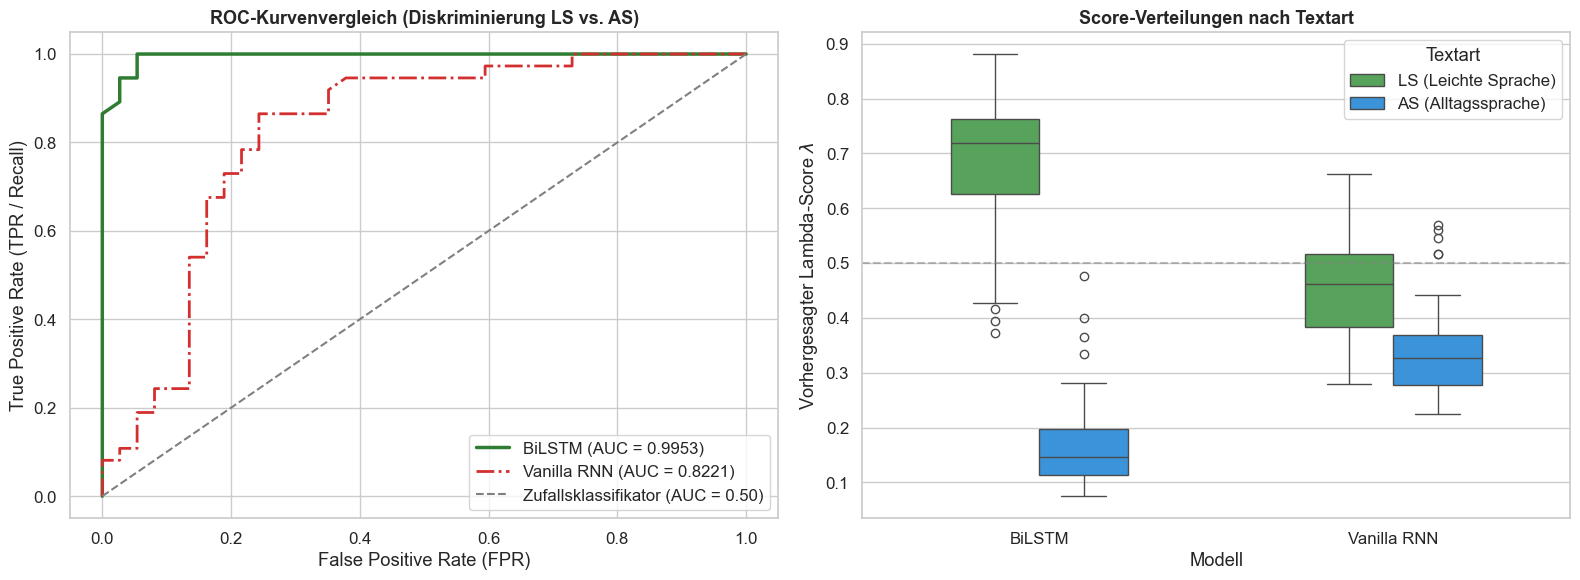

In [5]:
fig ,axes =plt .subplots (1 ,2 ,figsize =(16 ,6 ))

#ROC-Kurven
y_true =np .array ([1 ]*len (ls_preds_bilstm )+[0 ]*len (as_preds_bilstm ))
fpr_bilstm ,tpr_bilstm ,_ =roc_curve (y_true ,np .concatenate ([ls_preds_bilstm ,as_preds_bilstm ]))
fpr_rnn ,tpr_rnn ,_ =roc_curve (y_true ,np .concatenate ([ls_preds_rnn ,as_preds_rnn ]))
auc_bilstm =roc_auc_score (y_true ,np .concatenate ([ls_preds_bilstm ,as_preds_bilstm ]))
auc_rnn =roc_auc_score (y_true ,np .concatenate ([ls_preds_rnn ,as_preds_rnn ]))

axes [0 ].plot (fpr_bilstm ,tpr_bilstm ,color ="#2E7D32",lw =2.5 ,label =f"BiLSTM (AUC = {auc_bilstm :.4f})")
axes [0 ].plot (fpr_rnn ,tpr_rnn ,color ="#D32F2F",lw =2 ,linestyle ="-.",label =f"Vanilla RNN (AUC = {auc_rnn :.4f})")
axes [0 ].plot ([0 ,1 ],[0 ,1 ],color ="grey",linestyle ="--",label ="Zufallsklassifikator (AUC = 0.50)")
axes [0 ].set_title ("ROC-Kurvenvergleich (Diskriminierung LS vs. AS)",fontsize =13 ,fontweight ="bold")
axes [0 ].set_xlabel ("False Positive Rate (FPR)")
axes [0 ].set_ylabel ("True Positive Rate (TPR / Recall)")
axes [0 ].legend (loc ="lower right",frameon =True )

#Boxplot der Vorhersagen
df_box =pd .DataFrame ({
"Score":np .concatenate ([ls_preds_bilstm ,as_preds_bilstm ,ls_preds_rnn ,as_preds_rnn ]),
"Textart":["LS (Leichte Sprache)"]*len (ls_preds_bilstm )+["AS (Alltagssprache)"]*len (as_preds_bilstm )+["LS (Leichte Sprache)"]*len (ls_preds_rnn )+["AS (Alltagssprache)"]*len (as_preds_rnn ),
"Modell":["BiLSTM"]*(len (ls_preds_bilstm )+len (as_preds_bilstm ))+["Vanilla RNN"]*(len (ls_preds_rnn )+len (as_preds_rnn ))
})

sns .boxplot (x ="Modell",y ="Score",hue ="Textart",data =df_box ,ax =axes [1 ],palette =["#4CAF50","#2196F3"],width =0.5 )
axes [1 ].set_title ("Score-Verteilungen nach Textart",fontsize =13 ,fontweight ="bold")
axes [1 ].set_ylabel (r"Vorhergesagter Lambda-Score $\lambda$")
axes [1 ].axhline (0.5 ,color ="grey",linestyle ="--",alpha =0.5 )

plt .tight_layout ()
roc_box_path =os .path .join (PLOT_OUTPUT_DIR ,"compare_bilstm_vs_rnn_roc_box.png")
plt .savefig (roc_box_path ,dpi =300 ,bbox_inches ="tight")
print (f"ROC/Boxplot gespeichert unter: {roc_box_path }")
plt .show ()
